In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/processed/uci_household_5min.csv", index_col="datetime", parse_dates=True)

print(df.shape)
df.head()

(415053, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:20:00,4.2160,0.4180,234.840,18.40,0.0,1.0,17.0
2006-12-16 17:25:00,4.6616,0.4972,234.272,19.96,0.0,1.4,16.8
2006-12-16 17:30:00,3.8360,0.5116,234.204,16.56,0.0,1.2,16.8
2006-12-16 17:35:00,4.6684,0.4100,234.212,20.00,0.0,1.0,16.8
2006-12-16 17:40:00,3.9176,0.0616,235.890,16.76,0.0,0.0,17.0


In [12]:
df["pct_change"] = df["Global_active_power"].pct_change().fillna(0)
df["hour"] = df.index.hour
df["expected_for_hour"] = df.groupby("hour")["Global_active_power"].transform("mean")
df["deviation_from_hourly_norm"] = df["Global_active_power"] - df["expected_for_hour"]

anomaly_features = ["pct_change", "deviation_from_hourly_norm", "Voltage", "Global_reactive_power"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[anomaly_features])

print(X_scaled.shape)

(415053, 4)


In [15]:
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.005,
    random_state=42
)

df["iso_anomaly"] = iso_forest.fit_predict(X_scaled)
df["iso_score"] = iso_forest.decision_function(X_scaled)

print(df["iso_anomaly"].value_counts())

iso_anomaly
 1    412977
-1      2076
Name: count, dtype: int64


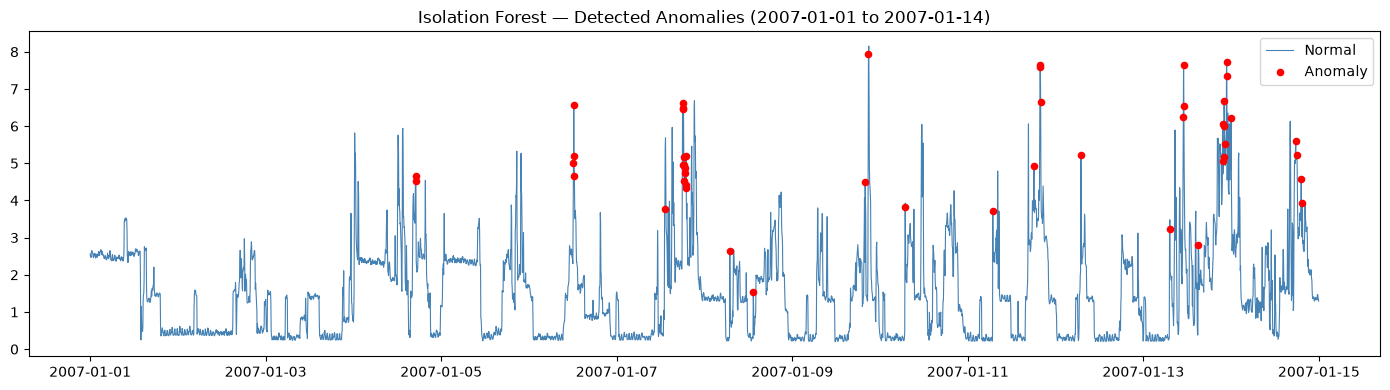

Total anomalies flagged (full dataset): 2076 (0.50%)


In [29]:
anomalies = df[df["iso_anomaly"] == -1]
window_start = "2007-01-01"
window_end = "2007-01-14"

df_window = df.loc[window_start:window_end]
anomalies_window = anomalies.loc[window_start:window_end]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_window.index, df_window["Global_active_power"], linewidth=0.8, color="steelblue", label="Normal")
ax.scatter(anomalies_window.index, anomalies_window["Global_active_power"], color="red", s=20, label="Anomaly", zorder=5)
ax.legend()
ax.set_title(f"Isolation Forest — Detected Anomalies ({window_start} to {window_end})")
plt.tight_layout()
plt.show()

print(f"Total anomalies flagged (full dataset): {len(anomalies)} ({len(anomalies)/len(df)*100:.2f}%)")

In [30]:
WINDOW = 12  # 60-minute sequences

def build_ae_sequences(data, window=WINDOW):
    n = len(data) - window
    return np.array([data[i:i+window] for i in range(n)])

X_seq = build_ae_sequences(X_scaled)
print(X_seq.shape)

(415041, 12, 4)


In [18]:
import tensorflow as tf

n_features = X_seq.shape[2]

autoencoder = tf.keras.Sequential([
    tf.keras.layers.LSTM(32, activation="relu", input_shape=(WINDOW, n_features), return_sequences=False),
    tf.keras.layers.RepeatVector(WINDOW),
    tf.keras.layers.LSTM(32, activation="relu", return_sequences=True),
    tf.keras.layers.TimeDistributed(tf.keras.layers.Dense(n_features))
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

c:\Users\JESNI\powerpredict\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 12, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 12, 4)          │           132 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,188 (51.52 KB)

 Trainable params: 13,188 (51.52 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
early_stop_ae = tf.keras.callbacks.EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)

history_ae = autoencoder.fit(
    X_seq, X_seq,  # input = target, since it's reconstructing itself
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_ae],
    verbose=1
)

Epoch 1/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 40s 6ms/step - loss: 0.2239
Epoch 2/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - loss: 0.1152
Epoch 3/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - loss: 0.0863
Epoch 4/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - loss: 0.0680
Epoch 5/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 0.0693
Epoch 6/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 0.0479
Epoch 7/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - loss: 0.0391
Epoch 8/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 0.0331
Epoch 9/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - loss: 0.0306
Epoch 10/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 37s 6ms/step - loss: 0.0256
Epoch 11/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 47s 7ms/step - loss: 0.0236
Epoch 12/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 0.0226
Epoch 13/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step - loss: 0.0197
Epoch 14/20
6486/6486 ━━━━━━━━━━━━━━━━━━━━ 45s 7ms/step - loss: 0.0171
Epoch 15/20
648

In [24]:
X_pred = autoencoder.predict(X_seq)
reconstruction_error = np.mean(np.abs(X_seq - X_pred), axis=(1, 2))

threshold = np.percentile(reconstruction_error, 98)
ae_anomaly = reconstruction_error > threshold

print(f"Threshold: {threshold:.4f}")
print(f"Anomalies flagged by autoencoder: {ae_anomaly.sum()} ({ae_anomaly.sum()/len(ae_anomaly)*100:.2f}%)")

12971/12971 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
Threshold: 0.1651
Anomalies flagged by autoencoder: 8301 (2.00%)


In [25]:
df_ae = df.iloc[WINDOW:].copy()
df_ae["ae_anomaly"] = ae_anomaly
df_ae["ae_score"] = reconstruction_error

df_ae["hybrid_anomaly"] = ((df_ae["iso_anomaly"] == -1) | (df_ae["ae_anomaly"] == True)).astype(int)

print(f"Isolation Forest only: {(df_ae['iso_anomaly']==-1).sum()}")
print(f"Autoencoder only: {df_ae['ae_anomaly'].sum()}")
print(f"Hybrid (either flags): {df_ae['hybrid_anomaly'].sum()}")
print(f"Both agree: {((df_ae['iso_anomaly']==-1) & (df_ae['ae_anomaly']==True)).sum()}")

Isolation Forest only: 2073
Autoencoder only: 8301
Hybrid (either flags): 10200
Both agree: 174


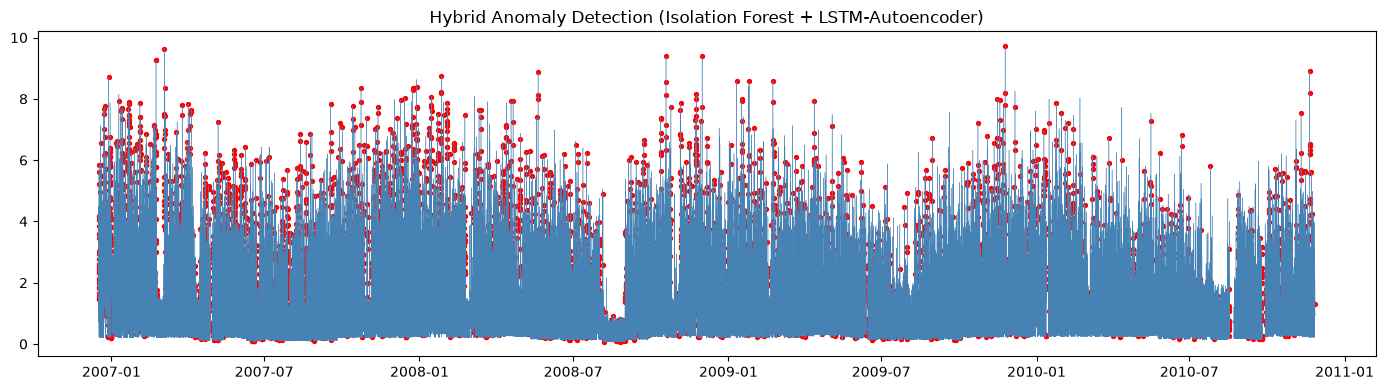

In [26]:
hybrid_flagged = df_ae[df_ae["hybrid_anomaly"] == 1]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_ae.index, df_ae["Global_active_power"], linewidth=0.3, color="steelblue")
ax.scatter(hybrid_flagged.index, hybrid_flagged["Global_active_power"], color="red", s=8)
ax.set_title("Hybrid Anomaly Detection (Isolation Forest + LSTM-Autoencoder)")
plt.tight_layout()
plt.show()

In [27]:
import os
os.makedirs("../src/models/anomaly", exist_ok=True)

import joblib
joblib.dump(iso_forest, "../src/models/anomaly/isolation_forest.pkl")
joblib.dump(scaler, "../src/models/anomaly/anomaly_scaler.pkl")
autoencoder.save("../src/models/anomaly/lstm_autoencoder.keras")

print("Both models saved")

Both models saved
